### ASTR 3300/5300: Astrostatistics
***N. Pol***
___

# Homework 3
### Due: Wednesday, Sep. 30 at 11.59pm CST
---

## Only one problem this week

This problem uses a dataset in `/coursework/homeworks/hw_data/`.

1) Read in `hw3_data_1.npy`. This is a (50 x 2) numpy array, with measurements in the first column and uncertainties in the second column. Using the analytic results for heteroscedastic Gaussian data from lectures, compute the sample mean and the standard error on the sample mean from for this data.

2) Reusing some approaches and tools from `Lecture_6`, write a ln-likelihood function for heteroscedastic Gaussian data, and use it in a fitting algorithm to find the best-fit mean. *Remember that scipy optimizers are set up to minimize functions.*

3) Using the same numerical technique from `Lecture_5`, compute the Fisher uncertainty estimate on the mean.

4) Using the bootstrap method, generate $1000$ bootstrap realizations of this dataset. *DO NOT use the `astroML` code. Write your own bootstrap function from scratch. Also recall that when resampling data, measurements and uncertainties should stay paired together.*

5) Repeat (2) with all $1000$ boostrap datasets to find the distribution of the sample mean. Plot a normalized histogram of these bootstrap means, and overplot a Gaussian pdf with the mean and std found in (1). Do these agree?

6) While we have fitted a heteroscedastic Gaussian to this data, let's try something else. Write some code to define a ln-likelihood for a Laplace distribution evaluated on this data. Fit simultaneously for the Laplace location parameter $\mu$ and scale parameter $\Delta$.

7) Compute the AIC values for the heteroscedastic Gaussian model and the Laplacian model. Which model is favored by the data?

8) Using the $1000$ bootstrap datasets from before, fit for the Laplacian $\mu$ and $\Delta$ for each. Make a nice `corner` plot of the distributions of $\mu$ and $\Delta$ that shows both the marginal $1$D distributions and the joint $2$D distribution. Make sure the plot has labels, shows the titles on each $1$D marginal panel, and has $68\%$ and $95\%$ levels.

9) Let's finish with a Fisher uncertainty estimate of the Laplacian parameters. Use the following code to install `numdifftools` which provides a simple way to compute derivatives. We can then compute the Hessian matrix, which is the matrix of the second derivatives of the user's function. This should be computed at the best-fit Laplacian parameters $\mu$ and $\Delta$. To finish, invert the matrix, and then take the square root. The diagonal entries will then be the Fisher uncertainties on $\mu$ and $\Delta$. How does these compare to the bootstrap distribution widths found in (8)?

In [33]:
!pip install numdifftools

In [80]:
import numdifftools as nd
H = nd.Hessian(f_lnlaplace)([beta_laplace[0], beta_laplace[1]])
sigma_laplace = np.linalg.inv(H)**0.5

### Solution

In [83]:
#Problem 1.1
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

# Load the data
data = np.load(r'.\hw_data\hw3_data_1.npy')

# First column = measurements
# Second column = uncertainties
x = data[:, 0]
sigma = data[:, 1]

print(data.shape)
print(data[:5])

mu_hat = np.sum(x / sigma**2) / np.sum(1 / sigma**2)

sigma_mu = 1 / np.sqrt(np.sum(1 / sigma**2))

print("Sample mean =", mu_hat)
print("Standard error =", sigma_mu)

(100, 2)
[[2.97207735 0.93806458]
 [1.98824293 1.40262692]
 [1.66981961 1.97120698]
 [3.96519709 0.60359301]
 [3.38541476 1.29698654]]
Sample mean = 3.9179920346060557
Standard error = 0.09481084100510956


In [85]:
#Problem1.2
import numpy as np
def f_gaussian(beta):
    mu = beta[0]

    # Lecture 5: heteroscedastic Gaussian / chi-square expression
    return np.sum(((x - mu) / sigma)**2)


# Starting guess
beta0 = [np.mean(x)]

# Lecture fitting approach: minimize the function
beta_gaussian = minimize(f_gaussian, beta0)

mu_gaussian = beta_gaussian.x[0]
mu_analytic = np.sum(x / sigma**2) / np.sum(1 / sigma**2)

print("Best-fit mean =", mu_gaussian)
print("Analytic mean =", mu_analytic)

Best-fit mean = 3.9179920193761633
Analytic mean = 3.9179920346060557


In [87]:
#Problem 1.3
# Fisher information from the curvature of the likelihood
F_mu = np.sum(1 / sigma**2)

# Fisher uncertainty
sigma_mu_fisher = 1 / np.sqrt(F_mu)
sigma_mu_analytic = 1 / np.sqrt(np.sum(1 / sigma**2))

print("Fisher uncertainty =", sigma_mu_fisher)
print("Analytic uncertainty =", sigma_mu_analytic)

Fisher uncertainty = 0.09481084100510956
Analytic uncertainty = 0.09481084100510956


In [89]:
#Problem1.4
def bootstrap(data):

    # Number of rows in the original dataset
    N = len(data)

    # Randomly select row numbers with replacement
    indices = np.random.randint(0, N, N)

    # Selecting whole rows keeps x and sigma paired
    data_boot = data[indices]

    return data_boot
Nboot = 1000

bootstrap_data = []

for i in range(Nboot):

    data_temp = bootstrap(data)

    bootstrap_data.append(data_temp)

bootstrap_data = np.array(bootstrap_data)

print(bootstrap_data.shape)

(1000, 100, 2)


Bootstrap mean = 3.920567713761399
Bootstrap std = 0.09467452374676215


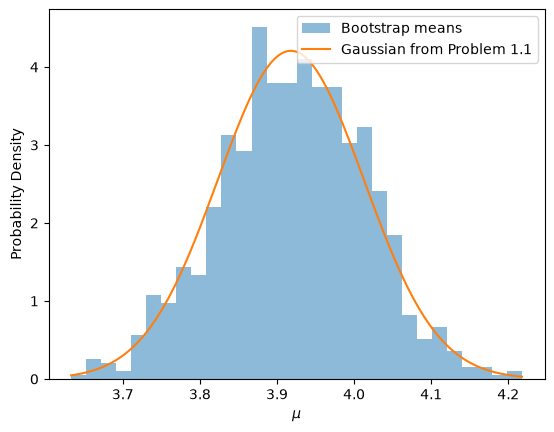

Analytic mean = 3.9179920346060557
Bootstrap mean = 3.920567713761399
Analytic uncertainty = 0.09481084100510956
Bootstrap std = 0.09467452374676215


In [91]:
#Problem 1.5
def f_gaussian_boot(beta, x_temp, sigma_temp):

    mu = beta[0]

    # Same heteroscedastic Gaussian expression as Problem 1.2
    return np.sum(((x_temp - mu) / sigma_temp)**2)
mu_bootstrap = []

for data_temp in bootstrap_data:

    # Column 0 = measurements
    x_temp = data_temp[:, 0]

    # Column 1 = uncertainties
    sigma_temp = data_temp[:, 1]

    # Starting guess
    beta0 = [np.mean(x_temp)]

    # Same fitting method as Problem 1.2
    fit_temp = minimize(
        f_gaussian_boot,
        beta0,
        args=(x_temp, sigma_temp)
    )

    # Save the fitted mean
    mu_bootstrap.append(fit_temp.x[0])

mu_bootstrap = np.array(mu_bootstrap)

print("Bootstrap mean =", np.mean(mu_bootstrap))
print("Bootstrap std =", np.std(mu_bootstrap))
plt.hist(
    mu_bootstrap,
    bins=30,
    density=True,
    alpha=0.5,
    label='Bootstrap means'
)
mu_grid = np.linspace(
    np.min(mu_bootstrap),
    np.max(mu_bootstrap),
    500
)

# Gaussian PDF centered on the Problem 1.1 result
gaussian_pdf = norm.pdf(
    mu_grid,
    loc=mu_analytic,
    scale=sigma_mu_analytic
)

plt.plot(
    mu_grid,
    gaussian_pdf,
    label='Gaussian from Problem 1.1'
)

plt.xlabel(r'$\mu$')
plt.ylabel('Probability Density')
plt.legend()

plt.show()
print("Analytic mean =", mu_analytic)
print("Bootstrap mean =", np.mean(mu_bootstrap))

print("Analytic uncertainty =", sigma_mu_analytic)
print("Bootstrap std =", np.std(mu_bootstrap))

In [92]:
#Problem 1.6
def f_lnlaplace(beta):

    mu = beta[0]
    Delta = beta[1]

    return np.sum(
        np.log(2 * Delta)
        + np.abs(x - mu) / Delta
    )
beta0 = [
    np.median(x),
    np.std(x)
]

fit_laplace = minimize(
    f_lnlaplace,
    beta0,
    bounds=[
        (None, None),
        (1e-8, None)
    ]
)

beta_laplace = fit_laplace.x

print("Laplace mu =", beta_laplace[0])
print("Laplace Delta =", beta_laplace[1])

Laplace mu = 4.085140592794518
Laplace Delta = 0.8822692496513068


In [97]:
#Problem 1.7
# Number of free parameters
k_gaussian = 1
k_laplace = 2

# Evaluate the functions at the best-fit parameters
lnL_gaussian = f_lngaussian(beta_gaussian)
lnL_laplace = f_lnlaplace(beta_laplace)

# AIC = 2k - 2 lnL
AIC_gaussian = 2 * k_gaussian - 2 * lnL_gaussian
AIC_laplace = 2 * k_laplace - 2 * lnL_laplace

print("Gaussian AIC =", AIC_gaussian)
print("Laplace AIC =", AIC_laplace)

NameError: name 'f_lngaussian' is not defined

(1000, 2)
mu bootstrap std = 0.13810074401662228
Delta bootstrap std = 0.07456614034848393


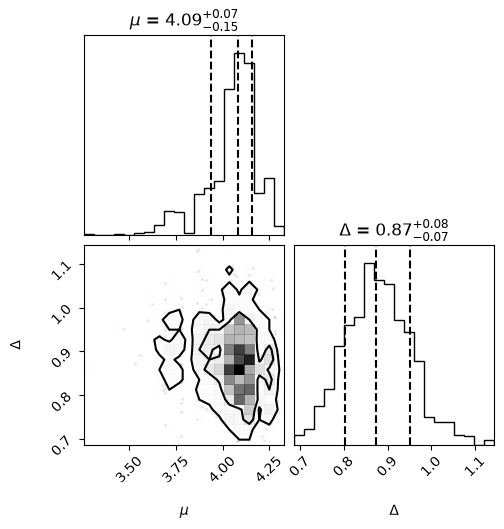

In [76]:
#Problem 1.8
def f_lnlaplace_boot(beta, x_temp):

    mu = beta[0]
    Delta = beta[1]

    return np.sum(
        np.log(2 * Delta)
        + np.abs(x_temp - mu) / Delta
    )


beta_laplace_boot = []

for data_temp in bootstrap_data:

    x_temp = data_temp[:, 0]

    beta0 = [
        np.median(x_temp),
        np.std(x_temp)
    ]

    fit_temp = minimize(
        f_laplace_boot,
        beta0,
        args=(x_temp,),
        bounds=[
            (None, None),   # mu can be anything
            (1e-8, None)    # Delta must stay positive
        ]
    )

    beta_laplace_boot.append(fit_temp.x)

beta_laplace_boot = np.array(beta_laplace_boot)

print(beta_laplace_boot.shape)
mu_laplace_boot = beta_laplace_boot[:, 0]
Delta_laplace_boot = beta_laplace_boot[:, 1]

print("mu bootstrap std =", np.std(mu_laplace_boot))
print("Delta bootstrap std =", np.std(Delta_laplace_boot))
import corner

fig = corner.corner(
    beta_laplace_boot,
    labels=[r'$\mu$', r'$\Delta$'],
    show_titles=True,
    quantiles=[0.16, 0.50, 0.84],
    levels=[0.68, 0.95]
)

In [60]:
#Problem 1.9
H = nd.Hessian(f_lnlaplace)([beta_laplace[0], beta_laplace[1]])

print(H)
H_inv = np.linalg.inv(H)

print(H_inv)
sigma_mu_laplace = np.sqrt(H_inv[0, 0])

sigma_Delta_laplace = np.sqrt(H_inv[1, 1])

print("Fisher uncertainty on mu =", sigma_mu_laplace)

print("Fisher uncertainty on Delta =", sigma_Delta_laplace)
print("mu:")
print("Fisher =", sigma_mu_laplace)
print("Bootstrap =", np.std(mu_laplace_boot))

print()

print("Delta:")
print("Fisher =", sigma_Delta_laplace)
print("Bootstrap =", np.std(Delta_laplace_boot))

NameError: name 'f_lnlaplace' is not defined

<span style="color:red">NP: missing #9. -3 pts </span>